[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kkipngenokoech/Material-Science/blob/main/Laboratory%2003%20-%20Machine%20Learning/neural_network_perovskite.ipynb)

In [4]:
!wget -q "https://raw.githubusercontent.com/kkipngenokoech/Material-Science/main/Laboratory%2003%20-%20Machine%20Learning/dataset_perovskite.csv"

In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import model_selection as ms

Load dataset

In [6]:
data = pd.read_csv("dataset_perovskite.csv", index_col=0)

X = data.drop(columns=["work function (eV)"]).values
Y = data["work function (eV)"].values

X_train, X_test, Y_train, Y_test = ms.train_test_split(X, Y, test_size=0.2, random_state=42)

def normalize(x, y, mean=None, std=None):
    X = x.T
    if mean is None:
        mean = np.mean(X, axis=1, keepdims=True)
        std = np.std(X, axis=1, keepdims=True)
    X = (X - mean) / std
    Y = y.reshape(1, -1)
    return X, Y, mean, std

X_train, Y_train, mean, std = normalize(X_train, Y_train)
X_test, Y_test, _, _ = normalize(X_test, Y_test, mean=mean, std=std)

print(X_train.shape, Y_train.shape)

(4, 387) (1, 387)


Optimize a two-layer neural network model using gradient descent

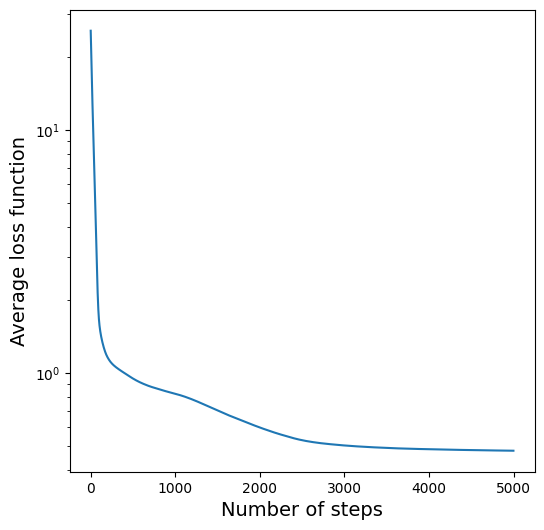

In [7]:
n0 = X_train.shape[0]
n1 = 8  # nb neurons in hidden layer

np.random.seed(98420)
W1 = np.random.randn(n1, n0) * 0.01
b1 = np.zeros((n1, 1))
W2 = np.random.randn(1, n1) * 0.01
b2 = np.zeros((1, 1))

def forward_propagate(X, W1, b1, W2, b2):
    Z1 = W1 @ X + b1
    A1 = np.maximum(0, Z1)  # relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = Z2  # output activation function = identity
    return Z1, A1, Z2, A2


n_steps = 5000
alpha = 0.01
J = []

for i in range(n_steps):
    # Forward propagation
    Z1, A1, Z2, A2 = forward_propagate(X_train, W1, b1, W2, b2)
    m = X_train.shape[1]
    avg_loss = 1./m * np.sum((A2 - Y_train) ** 2)
    J.append(avg_loss)

    # Backward propagation
    dA2 = 2./m * (A2 - Y_train)
    dZ2 = dA2
    dW2 = dZ2 @ A1.T
    db2 = np.sum(dZ2, axis=1, keepdims=True)

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * (Z1 > 0)  # dA1 * relu_derivative(Z1)
    dW1 = dZ1 @ X_train.T
    db1 = np.sum(dZ1, axis=1, keepdims=True)

    # Gradient descent
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2

plt.figure(figsize=(6, 6))
plt.plot(J)
plt.xlabel("Number of steps", fontsize=14)
plt.ylabel("Average loss function", fontsize=14)
plt.yscale("log")

Evaluate predictions on test set

(1, 387) (1, 387)


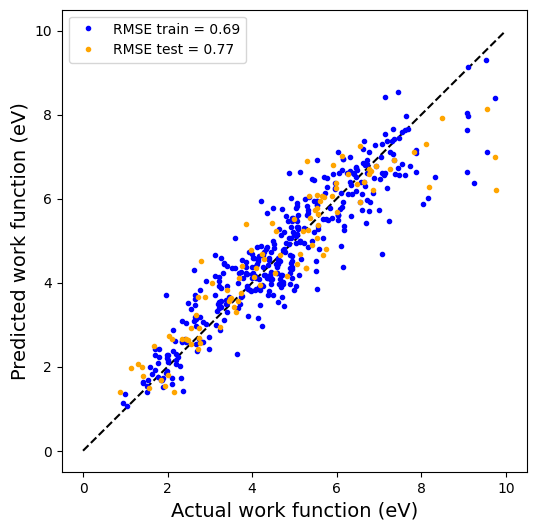

In [8]:
def rmse(yhat, y):
    return np.sqrt(np.mean((y - yhat) ** 2))


Z1, A1, Z2, pred_Y_train = forward_propagate(X_train, W1, b1, W2, b2)
Z1, A1, Z2, pred_Y_test = forward_propagate(X_test, W1, b1, W2, b2)

RMSE_train = rmse(pred_Y_train[0, :], Y_train[0, :])
RMSE_test = rmse(pred_Y_test[0, :], Y_test[0, :])

print(pred_Y_train.shape, Y_train.shape)

plt.figure(figsize=(6, 6))
plt.plot(np.arange(0, 11), np.arange(0, 11), "--", color="black")
plt.plot(Y_train[0, :], pred_Y_train[0, :], ".", color="blue", label=f"RMSE train = {RMSE_train:.2f}")
plt.plot(Y_test[0, :], pred_Y_test[0, :], ".", color="orange", label=f"RMSE test = {RMSE_test:.2f}")
plt.xlabel("Actual work function (eV)", fontsize=14)
plt.ylabel("Predicted work function (eV)", fontsize=14)
plt.legend()
plt.show()

Optimize a two-layer neural network model using Adam

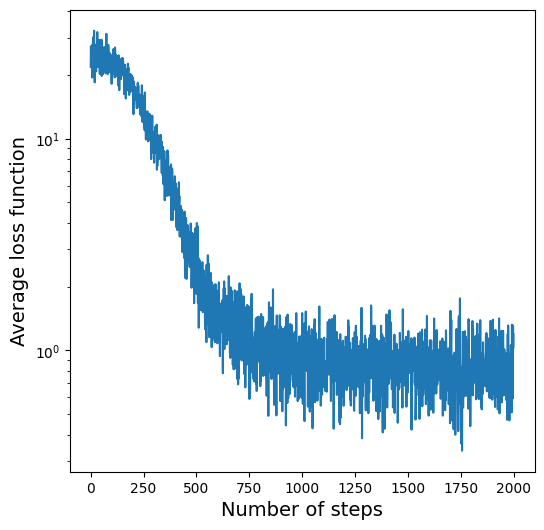

In [9]:
n0 = X_train.shape[0]
n1 = 8  # nb neurons in hidden layer

np.random.seed(98420)
W1 = np.random.randn(n1, n0) * 0.01
b1 = np.zeros((n1, 1))
W2 = np.random.randn(1, n1) * 0.01
b2 = np.zeros((1, 1))

def forward_propagate(X, W1, b1, W2, b2):
    Z1 = W1 @ X + b1
    A1 = np.maximum(0, Z1)  # relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = Z2  # output activation function = identity
    return Z1, A1, Z2, A2


n_steps = 2000
batch_size = X_train.shape[1] // 10

# Adam hyperparameters
alpha = 0.001
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

# Adam optimizer: initialize first and second moments
mW1 = np.zeros_like(W1)
vW1 = np.zeros_like(W1)
mb1 = np.zeros_like(b1)
vb1 = np.zeros_like(b1)

mW2 = np.zeros_like(W2)
vW2 = np.zeros_like(W2)
mb2 = np.zeros_like(b2)
vb2 = np.zeros_like(b2)

J = []

for i in range(1, n_steps+1):
    # Sample a random mini-batch without repeated indices
    m = X_train.shape[1]
    idx = np.random.choice(m, batch_size, replace=False)
    X_batch = X_train[:, idx]
    Y_batch = Y_train[:, idx]

    # Forward propagation
    Z1, A1, Z2, A2 = forward_propagate(X_batch, W1, b1, W2, b2)
    m_batch = X_batch.shape[1]
    avg_loss = (1.0 / m_batch) * np.sum((A2 - Y_batch) ** 2)
    J.append(avg_loss)

    # Backward propagation
    dA2 = 2./m_batch * (A2 - Y_batch)
    dZ2 = dA2
    dW2 = dZ2 @ A1.T
    db2 = np.sum(dZ2, axis=1, keepdims=True)

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * (Z1 > 0)  # dA1 * relu_derivative(Z1)
    dW1 = dZ1 @ X_batch.T
    db1 = np.sum(dZ1, axis=1, keepdims=True)

    # Adam optimizer: update first and second moments
    mW1 = beta1 * mW1 + (1 - beta1) * dW1
    vW1 = beta2 * vW1 + (1 - beta2) * dW1**2
    mb1 = beta1 * mb1 + (1 - beta1) * db1
    vb1 = beta2 * vb1 + (1 - beta2) * db1**2

    mW2 = beta1 * mW2 + (1 - beta1) * dW2
    vW2 = beta2 * vW2 + (1 - beta2) * dW2**2
    mb2 = beta1 * mb2 + (1 - beta1) * db2
    vb2 = beta2 * vb2 + (1 - beta2) * db2**2

    # Adam optimizer: bias correction
    mW1_hat = mW1 / (1 - beta1**i)
    vW1_hat = vW1 / (1 - beta2**i)
    mb1_hat = mb1 / (1 - beta1**i)
    vb1_hat = vb1 / (1 - beta2**i)

    mW2_hat = mW2 / (1 - beta1**i)
    vW2_hat = vW2 / (1 - beta2**i)
    mb2_hat = mb2 / (1 - beta1**i)
    vb2_hat = vb2 / (1 - beta2**i)

    # Adam optimizer: update parameters
    W1 -= alpha * mW1_hat / (np.sqrt(vW1_hat) + eps)
    b1 -= alpha * mb1_hat / (np.sqrt(vb1_hat) + eps)
    W2 -= alpha * mW2_hat / (np.sqrt(vW2_hat) + eps)
    b2 -= alpha * mb2_hat / (np.sqrt(vb2_hat) + eps)

plt.figure(figsize=(6, 6))
plt.plot(J)
plt.xlabel("Number of steps", fontsize=14)
plt.ylabel("Average loss function", fontsize=14)
plt.yscale("log")

(1, 387) (1, 387)


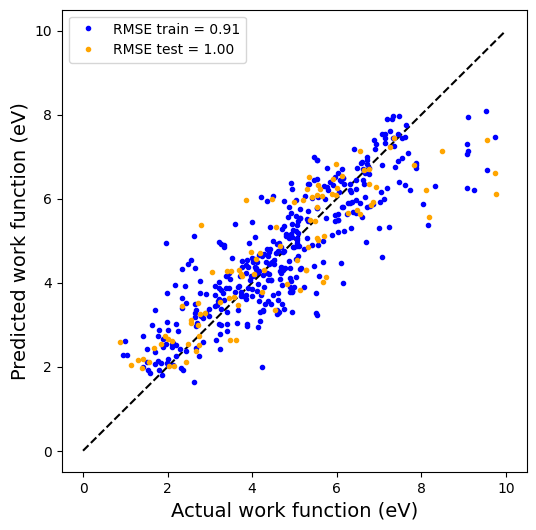

In [10]:
def rmse(yhat, y):
    return np.sqrt(np.mean((y - yhat) ** 2))


Z1, A1, Z2, pred_Y_train = forward_propagate(X_train, W1, b1, W2, b2)
Z1, A1, Z2, pred_Y_test = forward_propagate(X_test, W1, b1, W2, b2)

RMSE_train = rmse(pred_Y_train[0, :], Y_train[0, :])
RMSE_test = rmse(pred_Y_test[0, :], Y_test[0, :])

print(pred_Y_train.shape, Y_train.shape)

plt.figure(figsize=(6, 6))
plt.plot(np.arange(0, 11), np.arange(0, 11), "--", color="black")
plt.plot(Y_train[0, :], pred_Y_train[0, :], ".", color="blue", label=f"RMSE train = {RMSE_train:.2f}")
plt.plot(Y_test[0, :], pred_Y_test[0, :], ".", color="orange", label=f"RMSE test = {RMSE_test:.2f}")
plt.xlabel("Actual work function (eV)", fontsize=14)
plt.ylabel("Predicted work function (eV)", fontsize=14)
plt.legend()
plt.show()